In [28]:
import numpy as np
from scipy.signal import hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import Sleep_Scripts.Cleaned_feature_vis as F
import matplotlib.pyplot as plt

import pandas as pd


In [29]:
# Human frequency bands (AASM)
delta_band = [0.5,4]
theta_band = [4,8]
alpha_band = [8,13]
sigma_band = [12,14] # as per Gennaro & Ferrara Sleep spindles: an overview 2003
beta_band = [13,30]
gamma_band = [30,90] # as per Buzsaki & Wang Mechanisms of Gamma Oscillations 2012
noise_band = [0,0.5]
# total_band = [0,90]

### Functions

In [30]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [31]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [32]:
def fragment_join(subject, night, type):
    base = f"D:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"D:/EEG_Data_stage/{subject}/iEEG/U_sleep_API_10s"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

In [33]:
def create_plots(raw, hpc_channel, pfc_channel, states, output_dir, epoch_length, fs, window_length):
    # Bandpass EMG
    raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
    hpc_data = raw.get_data(picks=hpc_channel)[0]
    hpc_tag = hpc_channel
    raw_hpc = np.ravel(hpc_data)
    pfc_data = raw.get_data(picks=pfc_channel)[0]
    pfc_tag = pfc_channel
    raw_pfc = np.ravel(pfc_data)
    EMG = raw.get_data(picks='EMG1-EMG2')[0]
    EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
    EMG = EMG.reshape(-1, (epoch_length * fs))
    EMG = EMG.sum(axis=1)
    EMG = abs(hilbert(EMG))
    amp_thresh = [6,4]       
    time_win_thresh = [0.2,0.1]
    raw_hpc = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)[0]
    raw_pfc = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)[0]
    
    sleep_scoring = np.ravel(states)
    score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
    mapped_scores = np.array(sleep_scoring)
    sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
    num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}
    # Get EOG
    # EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])
    epochs = np.arange(len(mapped_scores))
    # # Establshing hypno epochs here prevents index mismatches later
    # raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
    # fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
    # noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))
    # noise_norm = wei_normalizing(noise)
    # delta_norm = wei_normalizing(delta)
    # theta_norm = wei_normalizing(theta)
    # sigma_norm = wei_normalizing(sigma)
    # beta_norm = wei_normalizing(beta)
    # gamma_norm = wei_normalizing(gamma)
    # alpha_norm = wei_normalizing(alpha)
    # #total_norm = wei_normalizing(total)
    # EMG_norm = wei_normalizing(EMG)
    # noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
    # EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')
    # # Index calculations
    # index_n = F.index_N(delta_norm, alpha_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)
    # 
    # index_r = F.index_R(delta_norm, sigma_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)
    # 
    # index_w = F.index_W(theta_norm, gamma_norm, EMG_norm)
    
    # min_len = min(len(epochs), len(index_w), len(index_n), len(index_r))
    # epochs = epochs[:min_len]
    # hypno_epochs = epochs
    # mapped_scores = mapped_scores[:min_len]
    # sleep_scoring = sleep_scoring[:min_len]
    # index_w = index_w[:min_len]
    # index_n = index_n[:min_len]
    # index_r = index_r[:min_len]
    
    # # Powerband plot
    # F.normalised_powers(EMG_norm, noise_norm, delta_norm, theta_norm, sigma_norm, beta_norm, gamma_norm, alpha_norm, hypno_epochs, sleep_scoring, output_dir)
    # # Normalised EMG
    # F.normalised_EMG(EMG_norm, output_dir)
    # # Raw signals
    # F.raw_signals(states, raw_hpc, raw_pfc, pfc_tag, hpc_tag, output_dir, fs, epoch_length)
    # # Indices vs a hypnogram
    # F.indices_vs_hypnogram(epochs, hypno_epochs, index_w, index_n, index_r, mapped_scores, output_dir)
    # # Index barplot
    # F.index_barplot(index_n, index_r, index_w, mapped_scores, output_dir)
    # # index PCA
    # F.index_pca(index_n, mapped_scores, index_r, index_w, output_dir)
    
    # Complexity analysis
    # Aperiodic fit
    # normalized_exponents, smoothed_exponents, valid_states, aperiodic_exponents = F.aperiodic_fit(pfc_data, states, fs, raw_pfc, output_dir, epoch_length)
    # Fractal power component
    eeg_in_epochs, mean_raw_slope_by_state, mean_smoothed_slope_by_state = F.fractal_power_component(states, subject, raw_pfc, output_dir, epoch_length, fs)
    # Slope per state
    smoothed_slopes = F.slope_per_state(output_dir, mean_raw_slope_by_state, mean_smoothed_slope_by_state,
                        states, eeg_in_epochs)
    # Fractal slope vs hypnogram
    F.fractal_slope_vs_hypnogram(subject, smoothed_slopes, output_dir, states)
    # # FOOOf report
    # F.fooof_report(output_dir, raw_pfc, fs)
    # # Aperiodic fit bar plot
    # F.aperiodic_fit_bar(valid_states, normalized_exponents, output_dir)
    # # Aperiodic fit violin plot
    # F.aperiodic_fit_violin(valid_states, normalized_exponents, output_dir)
    # 
    # # DFA over 10s
    # normalized_dfa = F.dfa_plot(np.ravel(pfc_data),  output_dir, epoch_length, fs)
    # # DFA per state
    # F.dfa_per_state(normalized_dfa, states, output_dir)
    # # Bar and violin for DFA
    # F.dfa_violin_and_bar(normalized_dfa, states, output_dir)
    # 
    # # MSE
    # normalized_mse = F.mse_plot(np.ravel(pfc_data), output_dir, epoch_length, fs)
    # # MSE per state
    # F.mse_per_state(normalized_mse, states, output_dir)
    # # MSE bar and violin plot
    # F.mse_violin_and_bar(normalized_mse, states, output_dir)
                

### Establish parameters

In [34]:
# Intra-cranial
electrodes = {"2":["TL05", "TLR06"],
              "7":["TL03", "TLR06"],
              "15":["TL05", "TLR01"], 
              "28":["TL07", "TLR06"], 
              "31":["TL05", "TLR12"], 
              "87":["TL05", "TLR01"]}

In [35]:
# # Extra-cranial
# electrodes = {
#     "2": ["Oz-Cz", "C3-Cz"],
#     "7": ["Oz-Cz", "C3-Cz"],
#     "15": ["Oz-Cz", "C3-Cz"], 
#     "28": ["Oz-Cz", "C3-Cz"], 
#     "31": ["Oz-Cz", "C3-Cz"],
#     "87": ["C4-Cz", "C3-Cz"],
# }

-----------------------------------Converting subject: 2-----------------------------------
Converting night: 1
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\U

-----------------------------------Finished creating plots for subject: 2; night 1-----------------------------------
Converting night: 2
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night2_01.vhdr...
Setting channel info structure...
Reading 0 ... 2950863  =      0.000 ... 11803.452 secs...
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night2_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599983  =      0.000 ... 14399.932 secs...
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night2_03.vhdr...
Setting channel info structure...
Reading 0 ... 3600015  =      0.000 ... 14400.060 secs...
Extracting parameters from D:/EEG_Data_stage/2/iEEG/converted_intra_upscale_strips\2_night2_04.vhdr...
Setting channel info structure...
Reading 0 ... 1058335  =      0.000 ...  4233.340 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\U

-----------------------------------Finished creating plots for subject: 2; night 2-----------------------------------
-----------------------------------Converting subject: 7-----------------------------------
Converting night: 1
Extracting parameters from D:/EEG_Data_stage/7/iEEG/converted_intra_upscale_strips\7_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 2256111  =      0.000 ...  9024.444 secs...
Extracting parameters from D:/EEG_Data_stage/7/iEEG/converted_intra_upscale_strips\7_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 2700031  =      0.000 ... 10800.124 secs...
Extracting parameters from D:/EEG_Data_stage/7/iEEG/converted_intra_upscale_strips\7_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 1990559  =      0.000 ...  7962.236 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from

...

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


-----------------------------------Finished creating plots for subject: 31; night 2-----------------------------------
-----------------------------------Converting subject: 87-----------------------------------
Converting night: 1
Extracting parameters from D:/EEG_Data_stage/87/iEEG/converted_intra_upscale_strips\87_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 2686143  =      0.000 ... 10744.572 secs...
Extracting parameters from D:/EEG_Data_stage/87/iEEG/converted_intra_upscale_strips\87_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 2700031  =      0.000 ... 10800.124 secs...
Extracting parameters from D:/EEG_Data_stage/87/iEEG/converted_intra_upscale_strips\87_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 2700031  =      0.000 ... 10800.124 secs...
Extracting parameters from D:/EEG_Data_stage/87/iEEG/converted_intra_upscale_strips\87_night1_04.vhdr...
Setting channel info structure...
Reading 0 ... 2700015  =      0.000 ..

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\U

-----------------------------------Finished creating plots for subject: 87; night 1-----------------------------------
Converting night: 2


IndexError: list index out of range

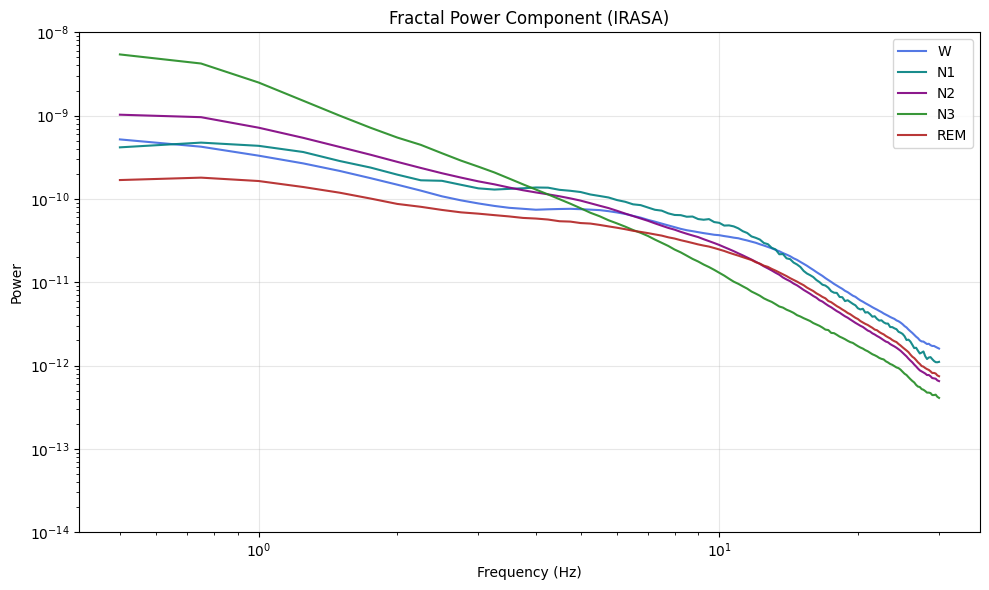

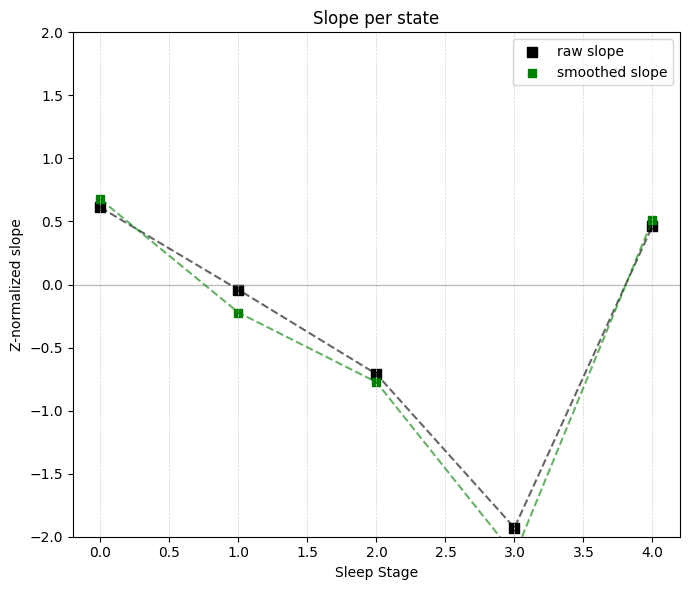

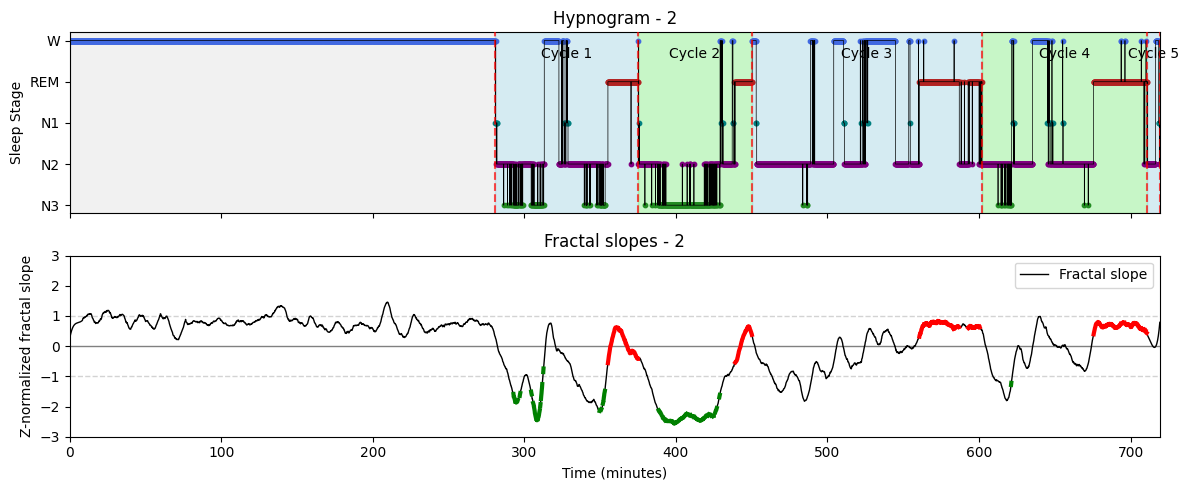

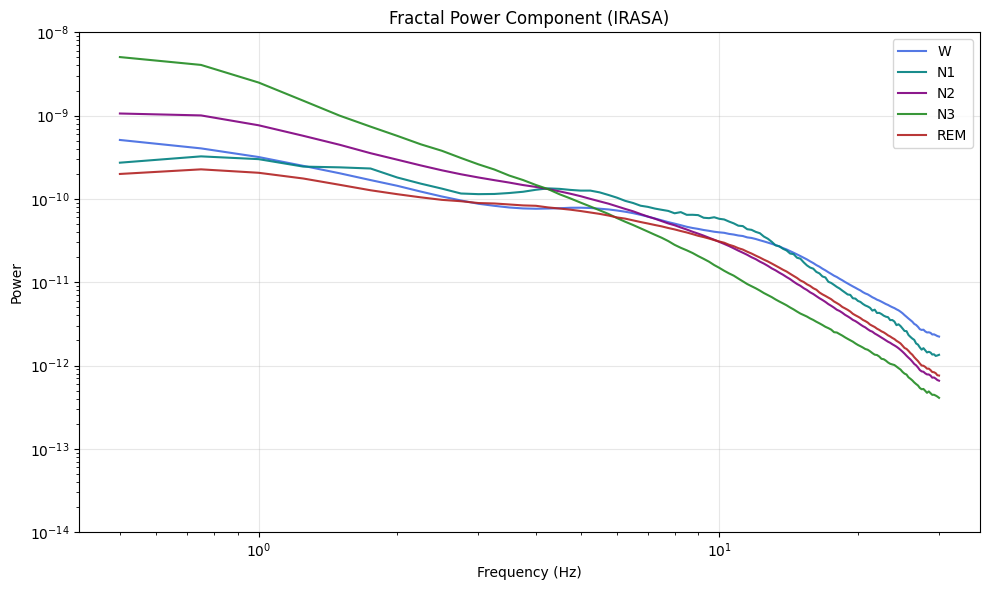

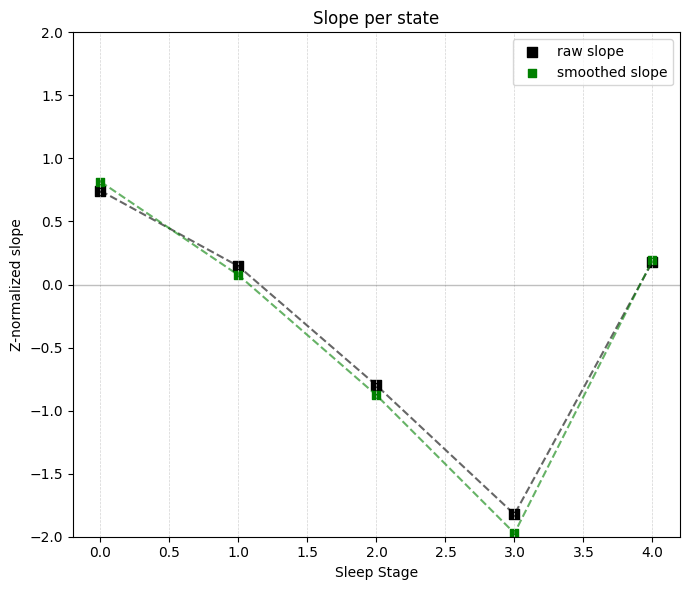

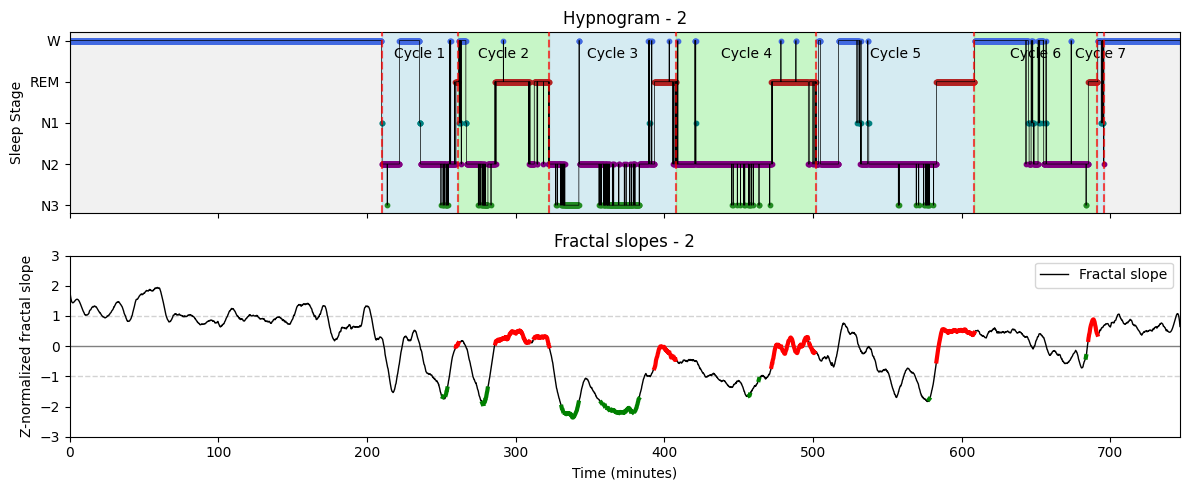

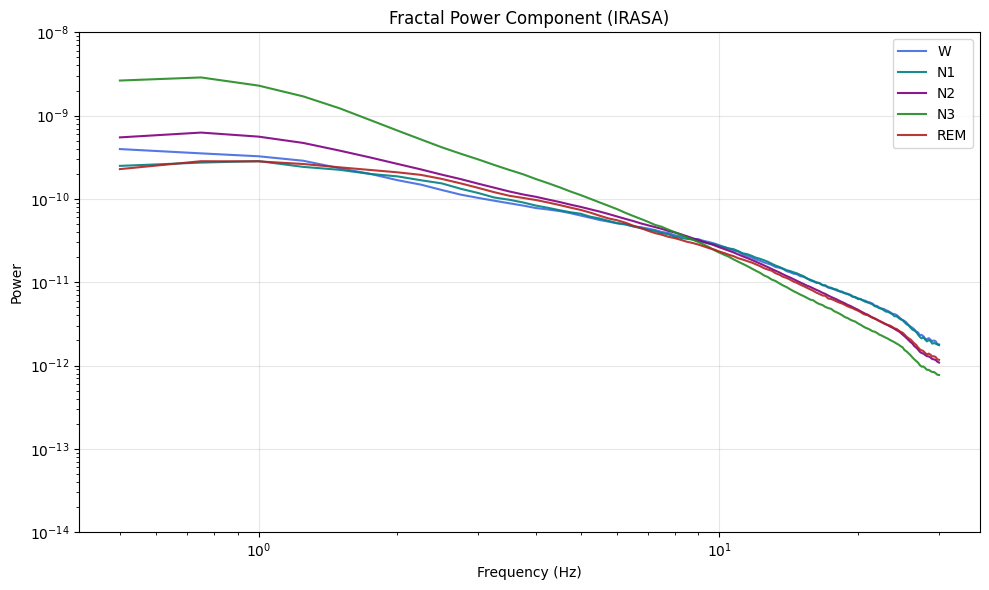

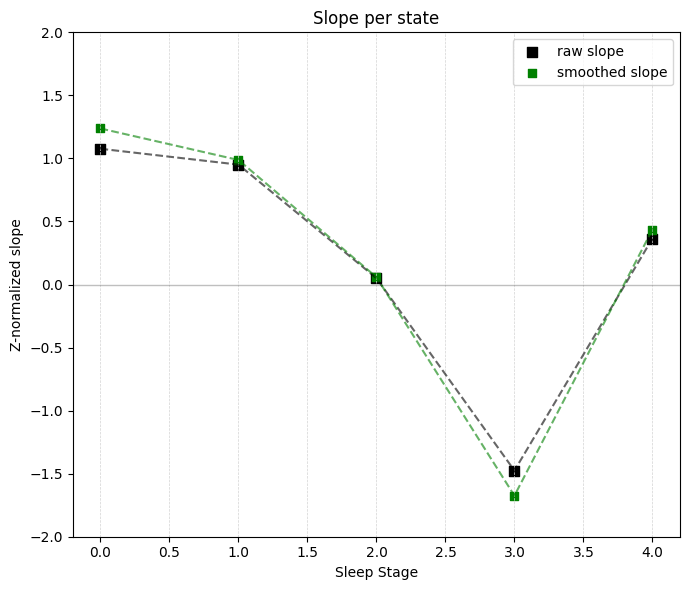

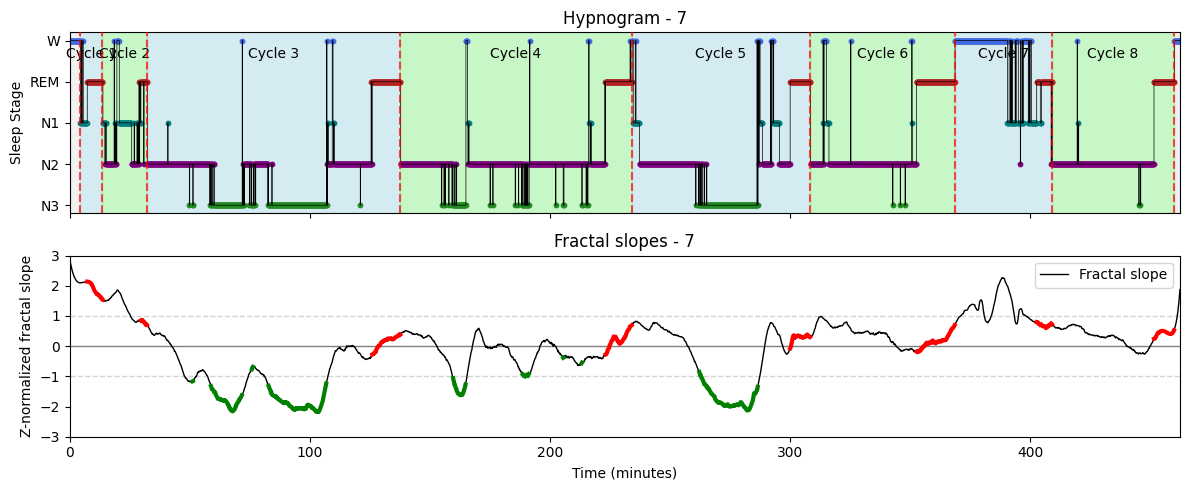

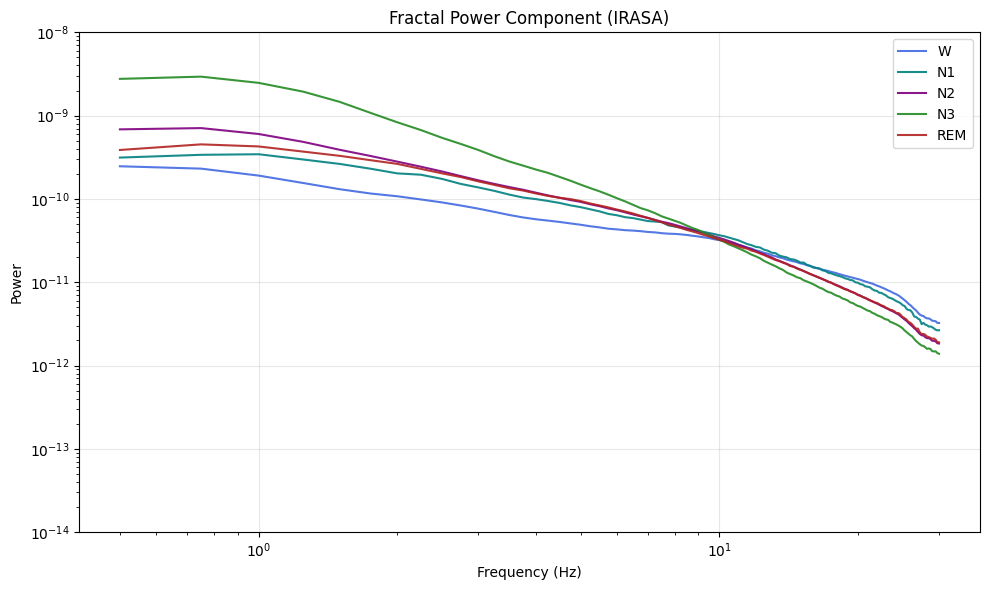

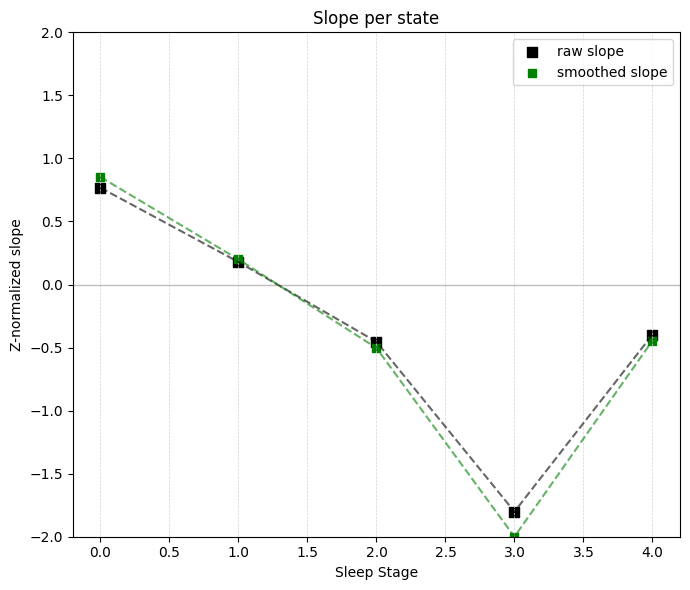

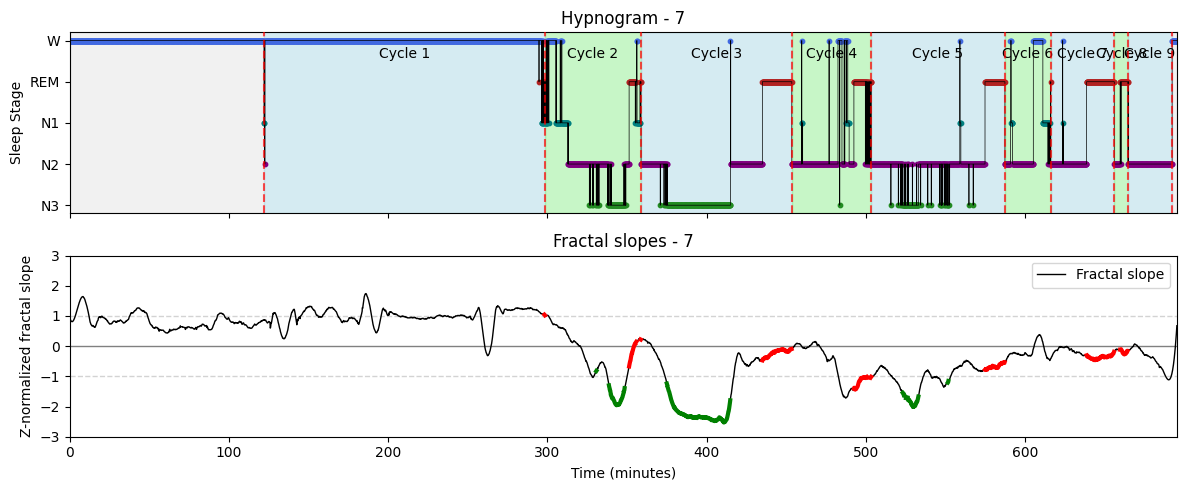

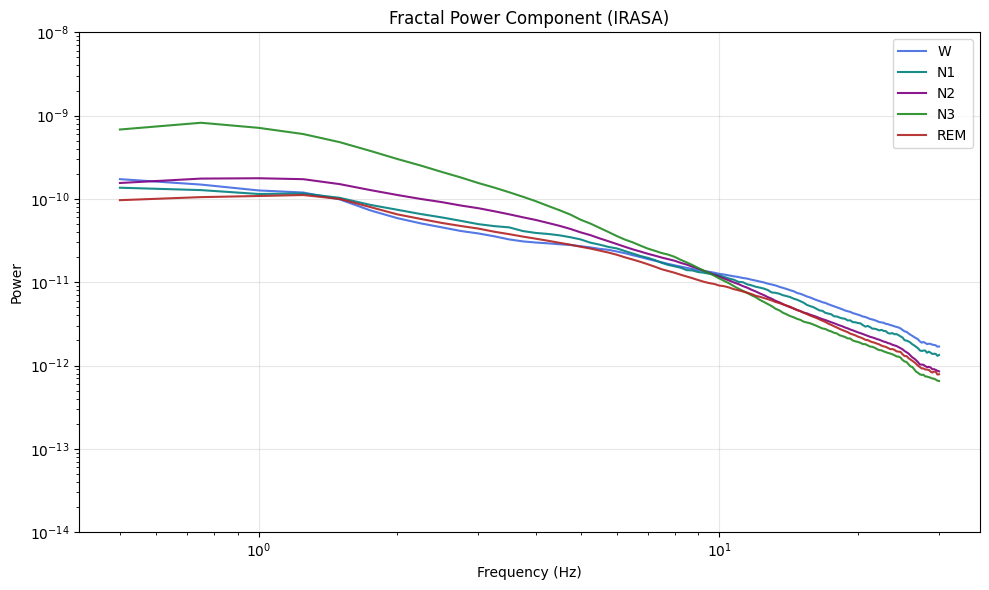

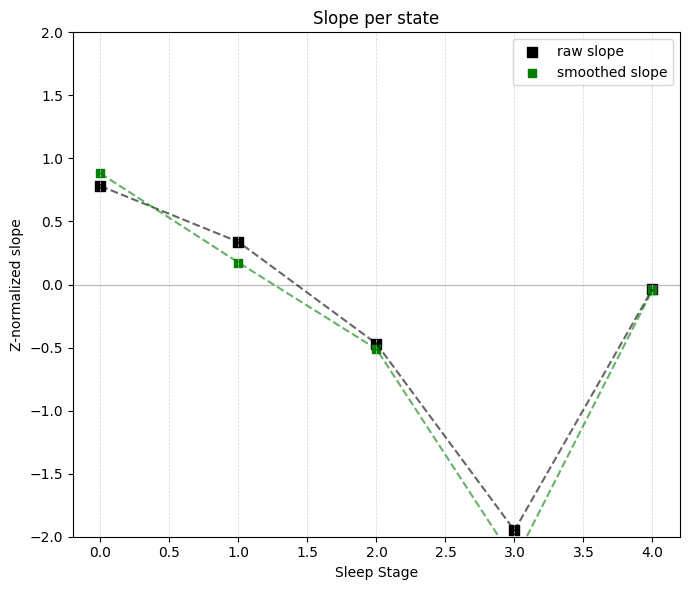

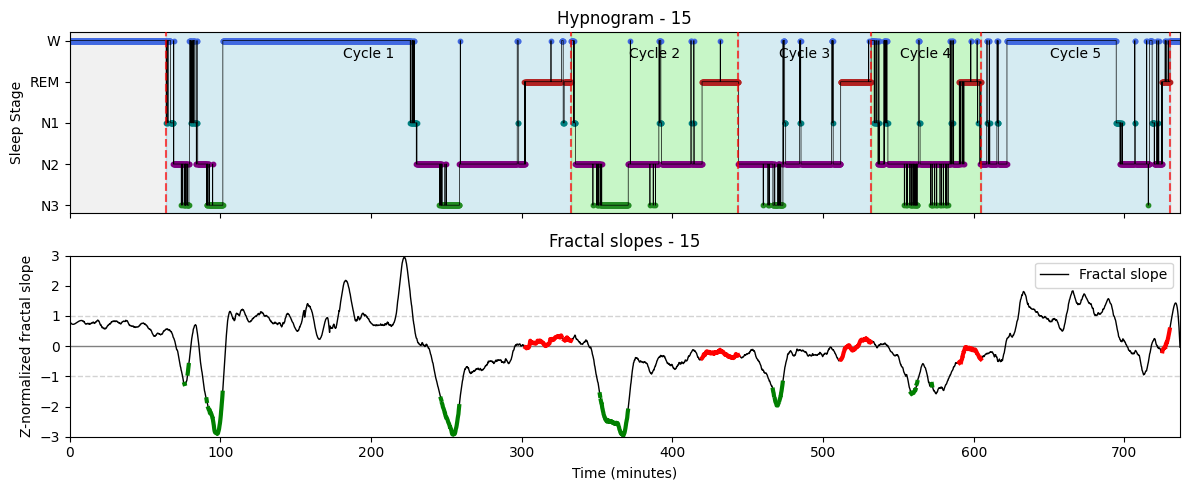

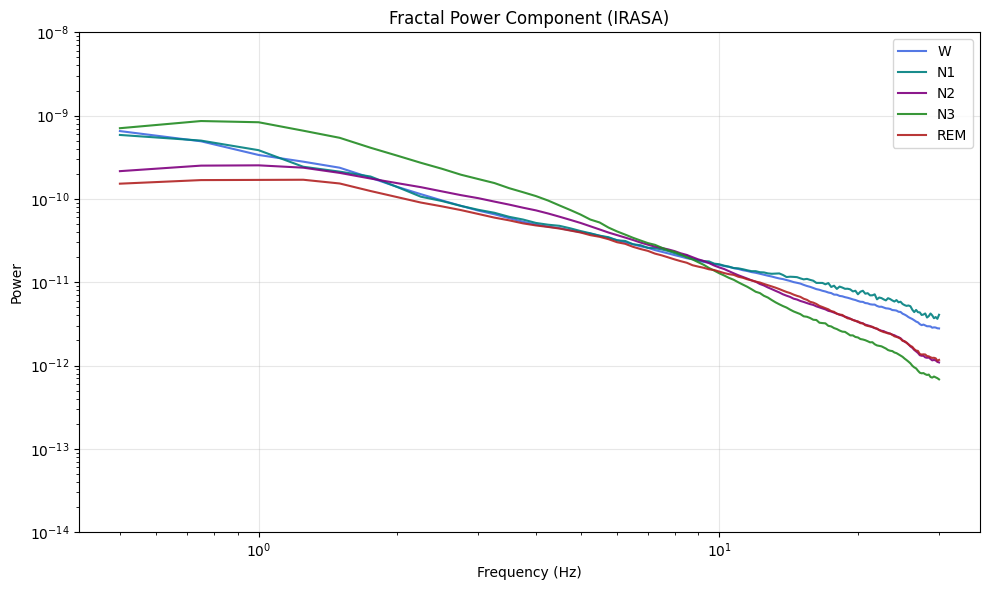

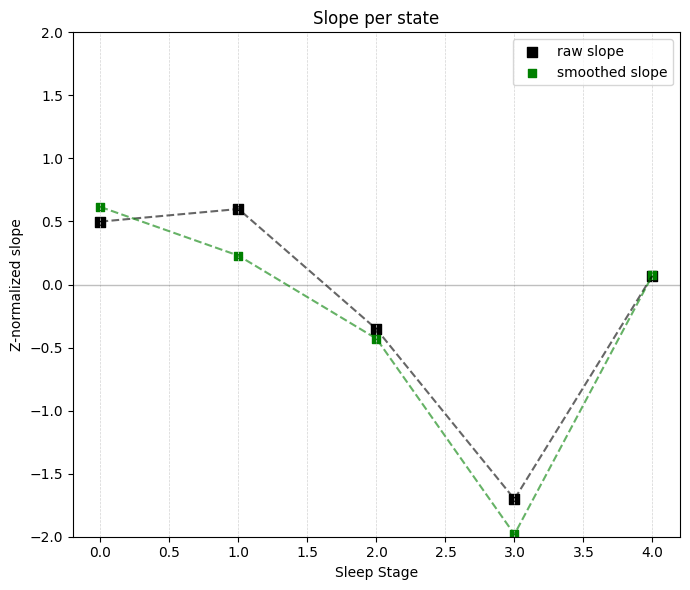

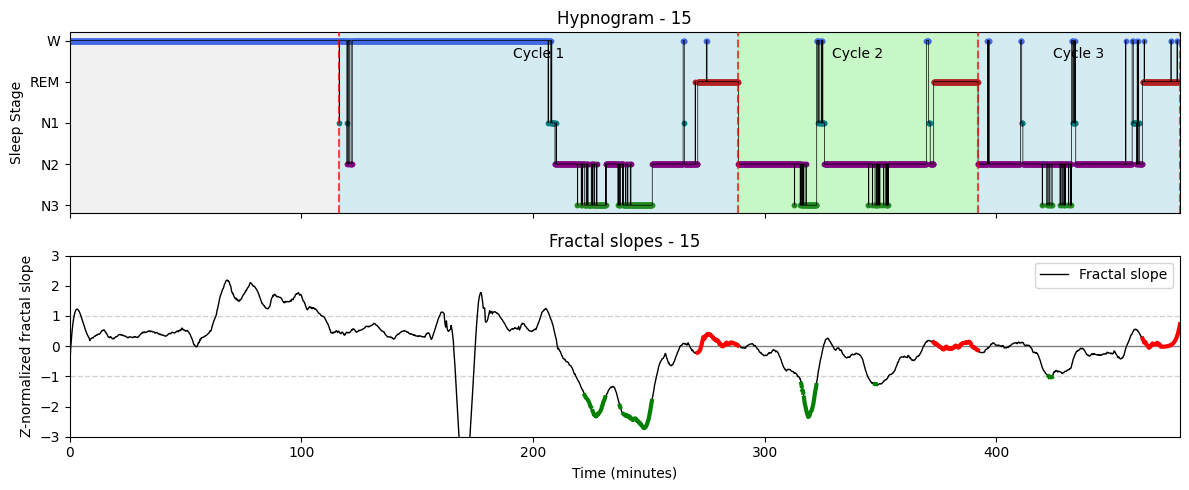

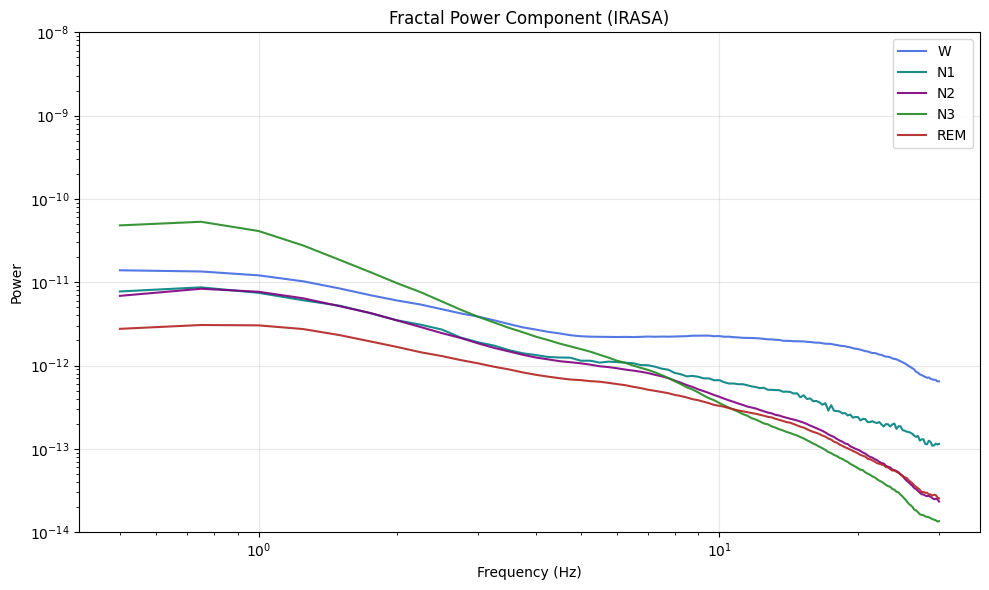

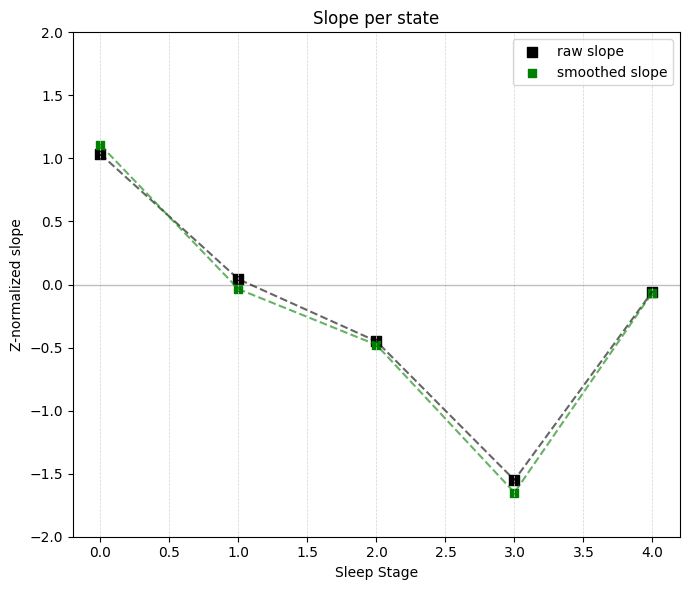

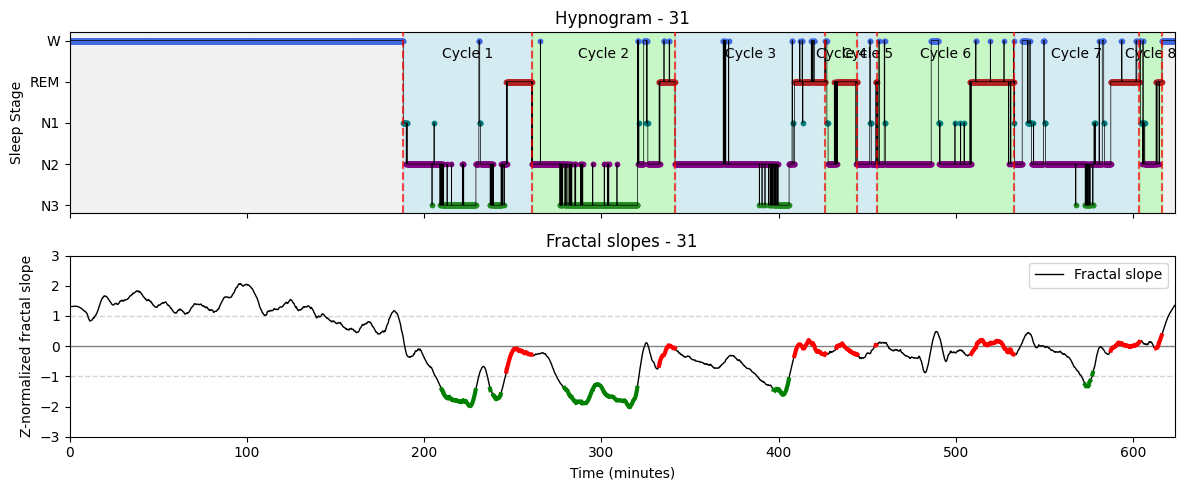

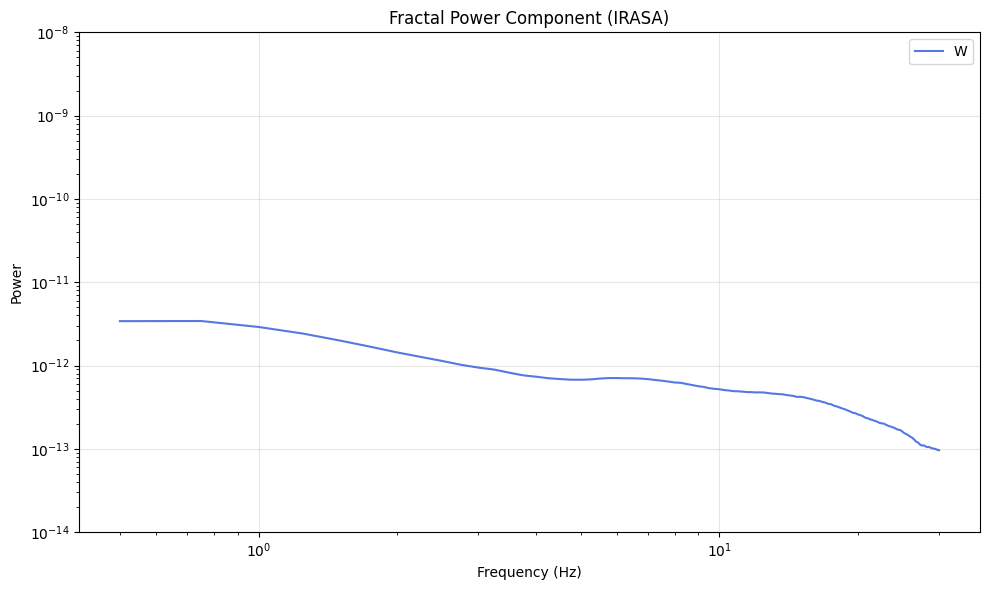

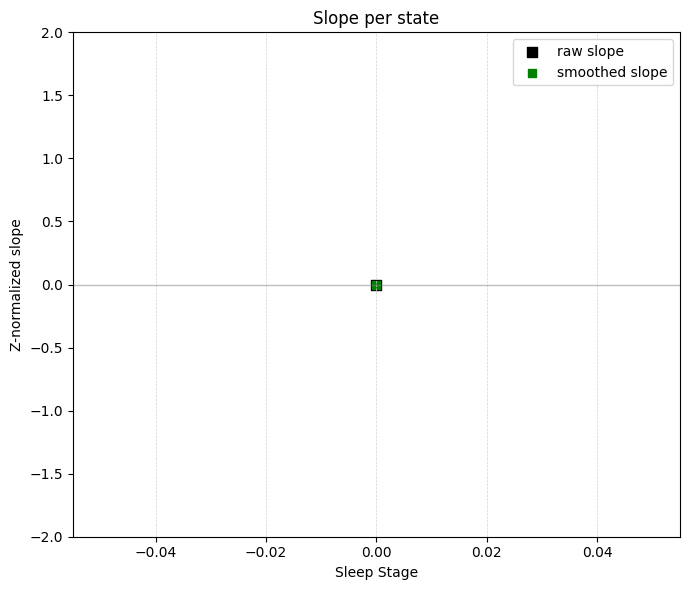

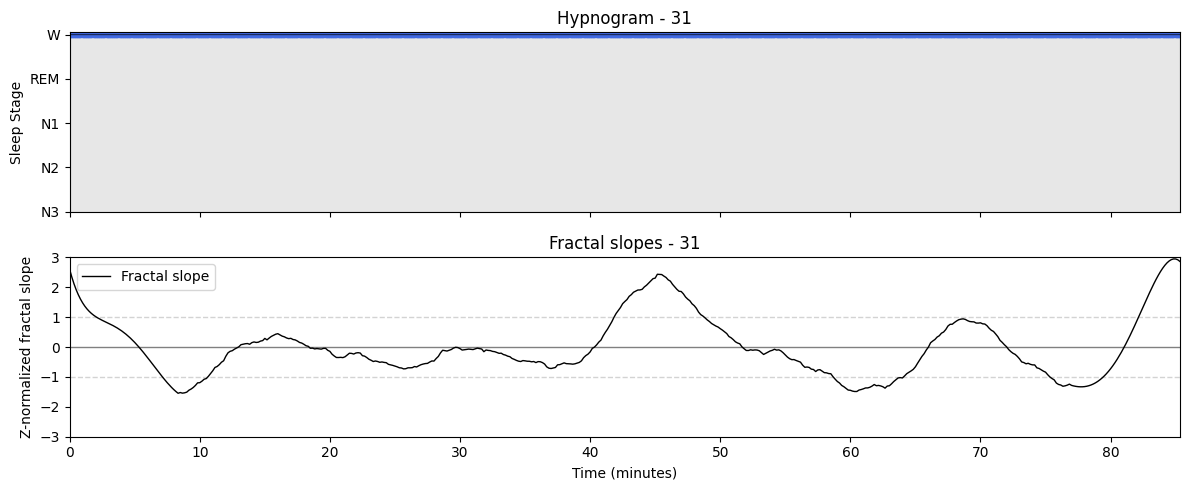

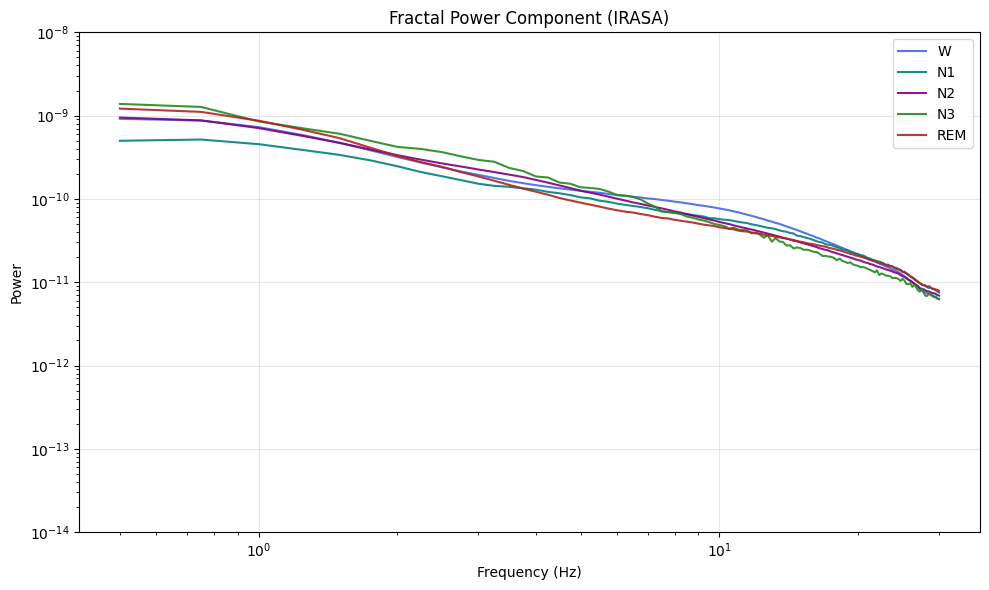

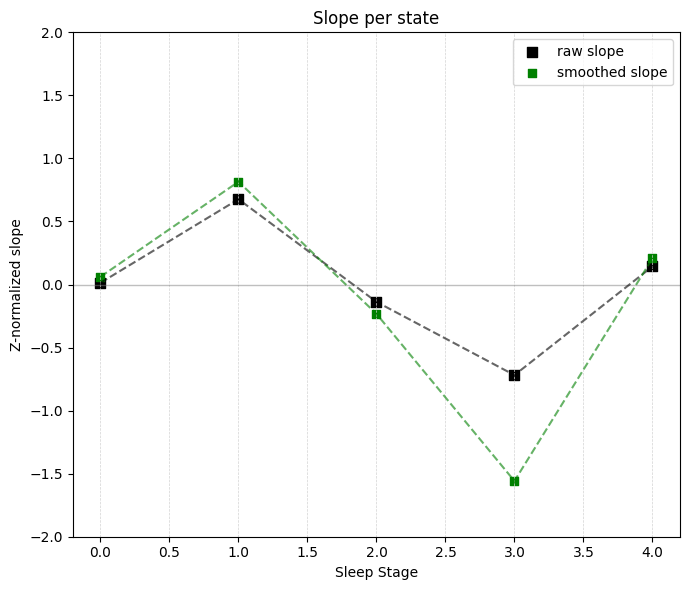

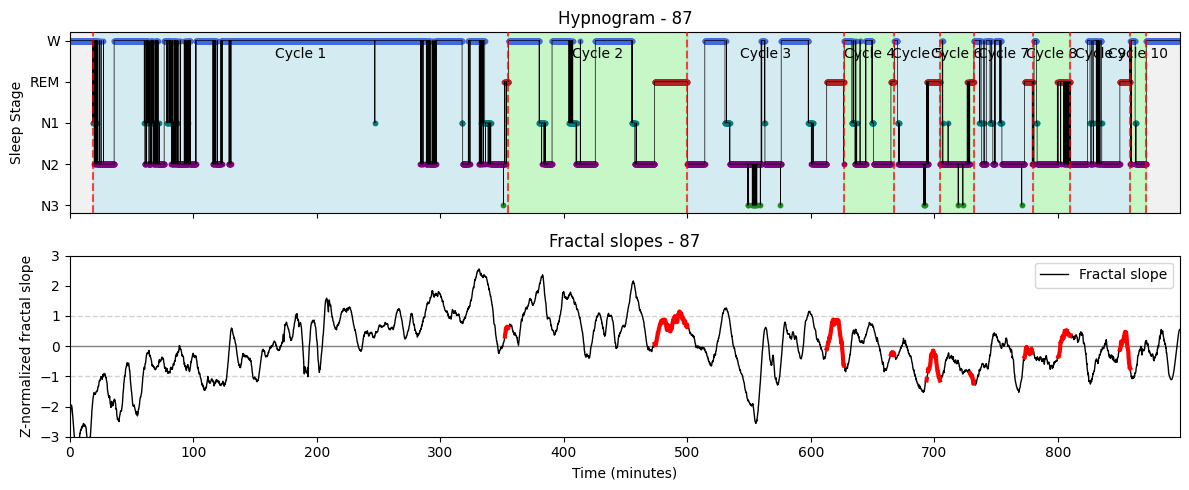

In [36]:
fs = 250
epoch_length = 10 
window_length = epoch_length * fs
base_dir = "D:/EEG_Data_stage"
processed_log = os.path.join(base_dir, "processed_subjects_slope_intra.txt")

# Load already processed subjects/nights
# Prevents rerunning the process for already processed subjects/nights
if os.path.exists(processed_log):
    with open(processed_log, "r") as f:
        processed = set(line.strip() for line in f if line.strip())
else:
    processed = set()

for file in os.listdir(base_dir):
    if file in electrodes.keys() and "28" not in file:
        print(f"-----------------------------------Converting subject: {file}-----------------------------------")
        channels = electrodes[file] 
        for night in range(1, 3):
            # try:
                subject_night = f"{file}_night{night}"
    
                # Skip if already processed
                if subject_night in processed:
                    print(f"Skipping {subject_night} — already processed.")
                    continue
    
                print(f"Converting night: {night}")
                subject = file
                night_str = f"{night}"
                file_type = "converted_intra_upscale_strips"
    
                hpc_channel = channels[0]
                pfc_channel = channels[1]
                output_dir = os.path.join(base_dir, "plots", file_type, subject, f"night{night_str}")
                os.makedirs(output_dir, exist_ok=True)
    
                files, scores_files = fragment_join(subject, night_str, file_type)
                raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
                raw = mne.concatenate_raws(raw_list)
                score_list = [np.load(f) for f in scores_files]
                states = np.concatenate(score_list)
    
                create_plots(raw, hpc_channel, pfc_channel, states, output_dir, epoch_length, fs, window_length)
    
                # Log successful processing
                with open(processed_log, "a") as f:
                    f.write(subject_night + "\n")
                processed.add(subject_night)
    
                print(f"-----------------------------------Finished creating plots for subject: {subject}; night {night}-----------------------------------")
            # except IndexError as e:
            #     print(f"Night {night} is out of range. Skipping {subject_night}.")
            #     print(f"Error: {e}")
